In [1]:
from sklearn.datasets import load_breast_cancer
import numpy as np



def explorer_dataset():
    X, y = load_breast_cancer(return_X_y=True)
    print("Forme des données (lignes, colonnes) :", X.shape)
    print("Classe 0 (maligne) :", np.bincount(y)[0],
          "\nClasse 1 (bénigne) :", np.bincount(y)[1])

    #print(list(data.target_names))
    """Charge le dataset et affiche ses caractéristiques de base.
    Doit afficher : nombre de lignes, nombre de colonnes,
    les classes possibles et leur répartition (équilibrée ou non ?).
    """
    # TODO : charger le dataset (return_X_y=True donne X et y séparés)
    # TODO : afficher la forme de X (combien de lignes, combien de colonnes)
    # TODO : compter et afficher combien d'exemples dans chaque classe

explorer_dataset()

Forme des données (lignes, colonnes) : (569, 30)
Classe 0 (maligne) : 212 
Classe 1 (bénigne) : 357


In [ ]:
def explorer_filtered_dataset():
    X, y = load_breast_cancer(return_X_y=True)
    filtre = (y==0)
    X = X[filtre]
    print("Forme des données (lignes, colonnes) :", X.shape)
    print("Classe 0 (maligne) :", np.bincount(y)[0])


explorer_filtered_dataset()

# décompte classe 0 maligne honnête

Forme des données (lignes, colonnes) : (212, 30)
Classe 0 (maligne) : 212


In [ ]:
# en pourcentage 

def explorer_dataset():
    X, y = load_breast_cancer(return_X_y=True)
    print("Forme des données (lignes, colonnes) :", X.shape)
    Classe0_pourcent = round(np.bincount(y)[0] / np.size(y), 2)
    Classe1_pourcent = round(np.bincount(y)[1] / np.size(y), 2)
    print("Classe 0 (maligne) :", Classe0_pourcent,
          "\nClasse 1 (bénigne) :", Classe1_pourcent)

    

explorer_dataset()

Forme des données (lignes, colonnes) : (569, 30)
Classe 0 (maligne) : 0.37 
Classe 1 (bénigne) : 0.63


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
modele = DecisionTreeClassifier(random_state=42)

def entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test):
    """Entraîne le modèle, prédit sur le test, renvoie l'accuracy.
    Doit renvoyer un float entre 0 et 1.
    """
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    return f"Accuracy : {accuracy_score(y_test, y_pred)}"

train_evaluate = entrainer_et_evaluer(modele, X_train, X_test, y_train, y_test)
train_evaluate
# TODO : entraîner le modèle sur les données d'apprentissage
# TODO : prédire sur le jeu de test
# TODO : calculer l'accuracy et la renvoyer




'Accuracy : 0.9122807017543859'

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
modele = DecisionTreeClassifier(random_state=42)
scores = []

def arene(X_train, X_test, y_train, y_test):
    models = {"KNN" : KNeighborsClassifier(), "LR" : LogisticRegression(max_iter=1000, random_state=42), "DT" : DecisionTreeClassifier(random_state=42)}
    for nom, model in models.items() : 
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        scores.append((nom, accuracy_score(y_test, y_pred)))
    return "\n".join(
        f"{nom} : {score:.2%}"
        for nom, score in scores
    )

    """Entraîne plusieurs modèles, renvoie un classement trié.
    Doit afficher un tableau lisible : nom de l'algo, accuracy.
    """


print(arene(X_train, X_test, y_train, y_test))



KNN : 91.23%
LR : 96.49%
DT : 91.23%


c:\Users\Math34\Mathieu\Projets Ipssi\Ipssi_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
from sklearn.cluster import KMeans
import pandas as pd


X, y = load_breast_cancer(return_X_y=True)


def clustering_aveugle(X):
    """Regroupe les données en 2 clusters sans les étiquettes.
    Renvoie les labels de cluster attribués à chaque point.
    """
    kmeans = KMeans(n_clusters=2, random_state=42, init="k-means++", n_init="auto").fit(X)
    kmeans.fit_predict(X)
    print(kmeans.labels_)
    print(np.mean(kmeans.labels_ == y))
    #print(kmeans.predict)
    #print(kmeans.cluster_centers_)
    # TODO : créer un KMeans à 2 clusters et renvoyer le cluster de chaque point
    #  (indice : une seule méthode fait l'entraînement ET la prédiction d'un coup)

print(clustering_aveugle(X))

data = load_breast_cancer()
feature_names = data.feature_names
df = pd.DataFrame(X)
df['vraie_classe'] = y
print(df.groupby('vraie_classe').mean()) 
print(feature_names)

# Comparaison sur chaque feature si les groupes bénin/malin sont différents.
# Ainsi on sait davantage si les features liées au cancer ont servi
# à la prédiction avec KMeans.

[0 0 0 1 0 1 0 1 1 1 1 0 0 1 1 1 1 0 0 1 1 1 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1
 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1
 1 0 1 0 0 1 1 1 0 0 1 0 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1
 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 1 0 1 1 1 1 1 0 0 1 1
 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 1 0 1 0
 1 0 0 0 1 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 0 1 1 1 0 0 

In [ ]:
# new dataset
from sklearn.datasets import load_wine
import numpy as np


def explorer_dataset(load):
    X, y = load(return_X_y=True)
    print("Forme des données (lignes, colonnes) :", X.shape)
    for i, count in enumerate(np.bincount(y)):
        print(f"Classe {i} : {round(count / np.size(y), 2)}")

explorer_dataset(load_wine)

#si une classe est moins représentée on le voit dans les résultats.

Forme des données (lignes, colonnes) : (178, 13)
Classe 0 : 0.33
Classe 1 : 0.4
Classe 2 : 0.27


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
modele = DecisionTreeClassifier(random_state=42)
scores = []

def arene(X_train, X_test, y_train, y_test):
    models = {"KNN" : KNeighborsClassifier(), "LR" : LogisticRegression(max_iter=1000, random_state=42), "DT" : DecisionTreeClassifier(random_state=42)}
    for nom, model in models.items() : 
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        scores.append((nom, accuracy_score(y_test, y_pred)))
    return "\n".join(
        f"{nom} : {score:.2%}"
        for nom, score in scores
    )

    """Entraîne plusieurs modèles, renvoie un classement trié.
    Doit afficher un tableau lisible : nom de l'algo, accuracy.
    """


print(arene(X_train, X_test, y_train, y_test))

#DecisionTreeClassifier passe derriere sur le vin par rapport au cancer du sein. 
#la fonction arene encaisse-t-elle un dataset à 3 classes sans aucune modification


KNN : 80.56%
LR : 94.44%
DT : 94.44%


c:\Users\Math34\Mathieu\Projets Ipssi\Ipssi_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


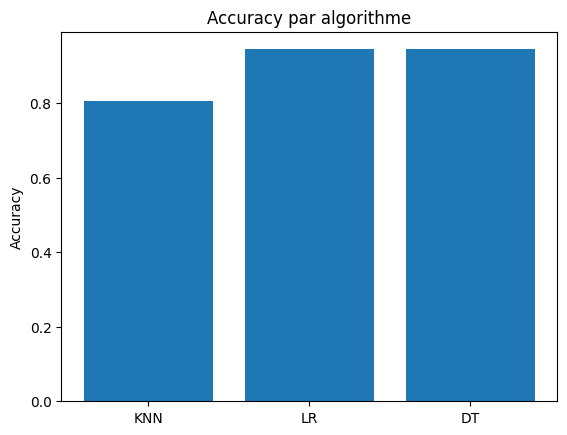

In [25]:
import matplotlib.pyplot as plt


algos = [nom for nom, score in scores]
accuracies = [score for nom, score in scores]

fig, ax = plt.subplots()

ax.bar(algos, accuracies)

ax.set_ylabel("Accuracy")
ax.set_title("Accuracy par algorithme")

plt.show()

In [35]:
from sklearn.metrics import confusion_matrix

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[11,  1,  0],
       [ 0, 14,  0],
       [ 0,  1,  9]])